In [1]:
%load_ext autoreload
%autoreload 2

from scripts.lattice import *
from scripts.plot import *
from scripts.obs import *
from scripts.utils import *
from triqs.gf import *

import seaborn as sns
#color_list = sns.color_palette() + sns.color_palette("Set2") + sns.color_palette("Set3")
color_list = (
    sns.color_palette("colorblind", 10) +
    sns.color_palette("Dark2", 8) +
    sns.color_palette("tab20", 20)
)

dim = 3
save_dir = f'data/{dim}d/rpa'

# single run with and without refinent (maybe also compare with tprc method)
# rest with more runs

Starting serial run at: 2026-05-11 00:28:36.554387


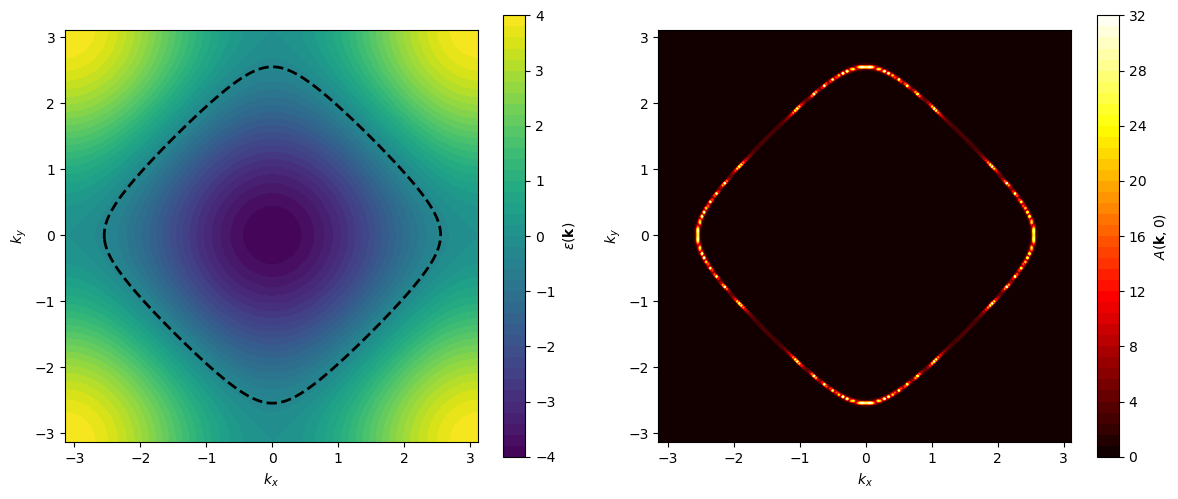

In [5]:
import numpy as np
import matplotlib.pyplot as plt

square = LATTICE(dim=2, tp=0.)
nk = 200

square.get_e_k(nk)
eps = square.e_k.data[:, 0, 0].real
eps = eps.reshape(nk, nk)
eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

_, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

# --- Compute A(k,0) ---
eta = 0.01  # broadening, tune to ~pi*T or Im Sigma(0)
mu = get_mu(e_k=square.e_k, n_goal=0.9, beta=1/1)
Ak0 = (1/np.pi) * eta / (eta**2 + (eps - mu)**2)

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: dispersion + bare FS ---
ax = axes[0]
cf = ax.contourf(kx, ky, eps, levels=50)
plt.colorbar(cf, ax=ax, label=r'$\varepsilon(\mathbf{k})$')
ax.contour(kx, ky, eps, levels=[mu], colors='black', linewidths=2)
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

# --- Plot 2: A(k,0) ---
ax = axes[1]
cf2 = ax.contourf(kx, ky, Ak0, levels=50, cmap='hot')
plt.colorbar(cf2, ax=ax, label=r'$A(\mathbf{k}, 0)$')
#ax.contour(kx, ky, eps, levels=[mu], colors='cyan', linewidths=1, linestyles='--')
ax.set_xlim(kx.min(), kx.max())
ax.set_ylim(ky.min(), ky.max())
ax.set_xlabel(r'$k_x$')
ax.set_ylabel(r'$k_y$')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

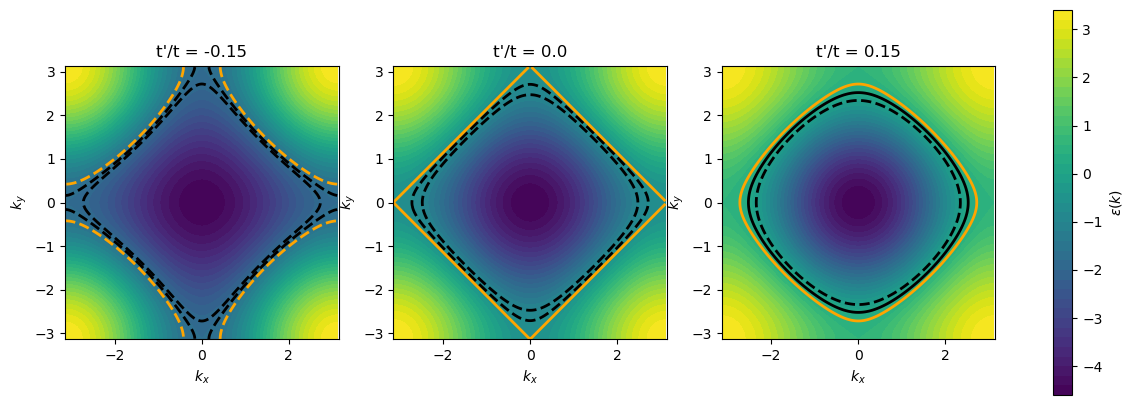

In [6]:
import numpy as np
import matplotlib.pyplot as plt

tp_list = [-0.15, 0., 0.15]

nk = 200

k_mesh, k_arr = square.get_k_mesh(nk)
kx = k_arr[:, 0].reshape(nk, nk) - np.pi
ky = k_arr[:, 1].reshape(nk, nk) - np.pi

T = 0.01
n_list = [0.8, 0.9, 1.]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, tp in zip(axes, tp_list):
    square = LATTICE(dim=2, tp=tp)
    
    square.get_e_k(nk)
    eps = square.e_k.data[:, 0, 0].real
    eps = eps.reshape(nk, nk)
    eps = np.roll(np.roll(eps, nk//2, axis=0), nk//2, axis=1)

    cf = ax.contourf(kx, ky, eps, levels=50)

    mu_list = [get_mu(e_k=square.e_k, n_goal=n, beta=1/T) for n in n_list]
    ax.contour(kx, ky, eps, levels=mu_list[:-1], colors='black', linewidths=2)
    ax.contour(kx, ky, eps, levels=[mu_list[-1]], colors='orange', linewidths=2)

    ax.set_xlim(-np.pi, np.pi)
    ax.set_ylim(-np.pi, np.pi)
    ax.set_xlabel(r'$k_x$')
    ax.set_ylabel(r'$k_y$')
    ax.set_title(f"t'/t = {tp}")
    ax.set_aspect('equal')

fig.colorbar(cf, ax=axes, label=r'$\varepsilon(k)$')
plt.show()

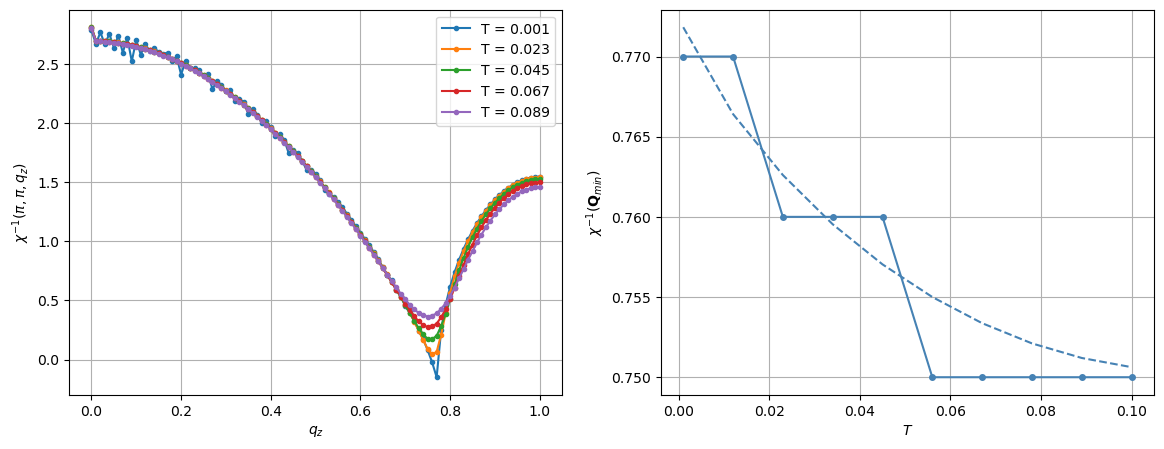

In [60]:
n = 0.8
T_list = np.linspace(0.001, 0.1, 10)
U = 3

nk = 200
cube = LATTICE()
cube.get_e_k(nk=nk)
cube.get_phase_k(nk)

fig = plt.figure(figsize=(14, 5))
ax = [fig.add_subplot(1,2,1),
    fig.add_subplot(1,2,2)]

ax[0].set_xlabel('$q_z$')
ax[0].set_ylabel(r'$\chi^{-1}(\pi,\pi,q_z)$')

ax[1].set_xlabel('$T$')
ax[1].set_ylabel(r'$\chi^{-1}(\mathbf{Q}_{min})$')

qz_path = np.linspace(0., 1., nk//2+1)
Qz = []
Qz_refined = []
for i, T in enumerate(T_list):
    mu = get_mu(cube.e_k, n, 1/T)

    invchi = []
    for qz in qz_path:
        q = np.array([1.,1.,qz])

        e_k, e_kq = cube.get_e_kq(q, 'coarse')
        S_k = e_k*0
        invchi.append(1/lindhard(mu, 1/T, e_k, e_kq, S_k, S_k) - U)

    if i%2 == 0:
        ax[0].plot(qz_path, invchi, 'o-', markersize=3, label=f'T = {T:.3f}')

    idx = np.argmin(invchi)
    Qz.append(qz_path[np.argmin(invchi)])
    #ax[0].axvline(Qz[-1], linestyle='--', color=color)

    start = qz_path[0]
    end   = qz_path[-1]
    step  = 1 / (len(qz_path) - 1)

    def invchi0(s):

        qz_pt = start + s * (end - start)
        q_pt = np.array([1.,1.,qz_pt])
        e_k_arr, e_kq_arr = cube.get_e_kq(q_pt, 'fine')

        return 1/lindhard(mu, 1/T, e_k_arr, e_kq_arr, S_k, S_k) - U

    s0 = idx / (len(qz_path) - 1)
    res = minimize_scalar(invchi0, method='bounded', bounds=(max(0, s0 - 5*step), min(1, s0 + 5*step)))

    s_min = res.x
    Qz_refined.append(start + s_min * (end - start))
    
ax[1].plot(T_list, Qz, 'o-', markersize=4, color='steelblue')
ax[1].plot(T_list, Qz_refined, '--', markersize=4, color='steelblue')
ax[0].legend()

for a in ax:
    a.grid()
plt.show()

[Parallel(n_jobs=11)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=11)]: Done   2 out of  11 | elapsed:    3.0s remaining:   13.5s
[Parallel(n_jobs=11)]: Done   4 out of  11 | elapsed:    3.2s remaining:    5.7s
[Parallel(n_jobs=11)]: Done   6 out of  11 | elapsed:    3.7s remaining:    3.1s
[Parallel(n_jobs=11)]: Done   8 out of  11 | elapsed:    4.6s remaining:    1.7s
[Parallel(n_jobs=11)]: Done  11 out of  11 | elapsed:    4.9s finished


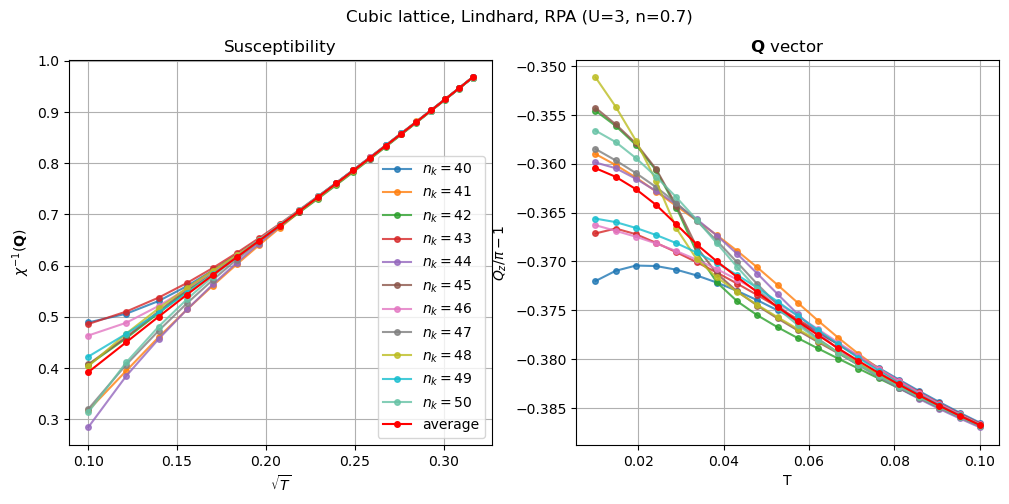

In [ ]:
U = 3
n = 0.7
T_list = np.linspace(0.001, 0.01, 20)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Lindhard, RPA (U={U}, n={n})'

nk_list = list(range(140, 151, 1))
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True} for nk in nk_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=11)

results_avg = results_list[-1].copy()
results_avg['invchi'] = sum([results['invchi'] for results in results_list])/len(results_list)
results_avg['Q'] = sum([results['Q'] for results in results_list])/len(results_list)

fig = None
for results in results_list:
    nk = results['nk']
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5,
                        title=title, label=f'$n_k={nk}$', figure=fig, alpha=0.8)
    
fig, _ = pcut_chi(results_avg, 'T', plot_Q=(0,0,1), fit=False, x_exp=0.5,
                    title=title, label=f'average', figure=fig, color='red')

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Starting serial run at: 2026-05-10 17:07:36.513772
Starting serial run at: 2026-05-10 17:07:36.513941
Starting serial run at: 2026-05-10 17:07:36.520056
Starting serial run at: 2026-05-10 17:07:36.571053
Starting serial run at: 2026-05-10 17:07:36.573867
[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed:  8.4min remaining: 12.6min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed:  8.5min remaining:  5.7min


n = 0.6 : ampl = 3.1740408075090834, exp = 0.5885428477379999, Tc = -0.06847717766325742
n = 0.65 : ampl = 2.7539761658982482, exp = 0.5505048006902485, Tc = -0.034281648129202105
n = 0.7 : ampl = 3.2483204411915962, exp = 0.6589795603591738, Tc = -0.023044947321150616
n = 0.75 : ampl = 2.502413654546775, exp = 0.5520907358881966, Tc = 0.00010859458854027088
n = 0.8 : ampl = 2.338332059310279, exp = 0.5380124652241255, Tc = 0.01837129925213769


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed:  8.7min finished


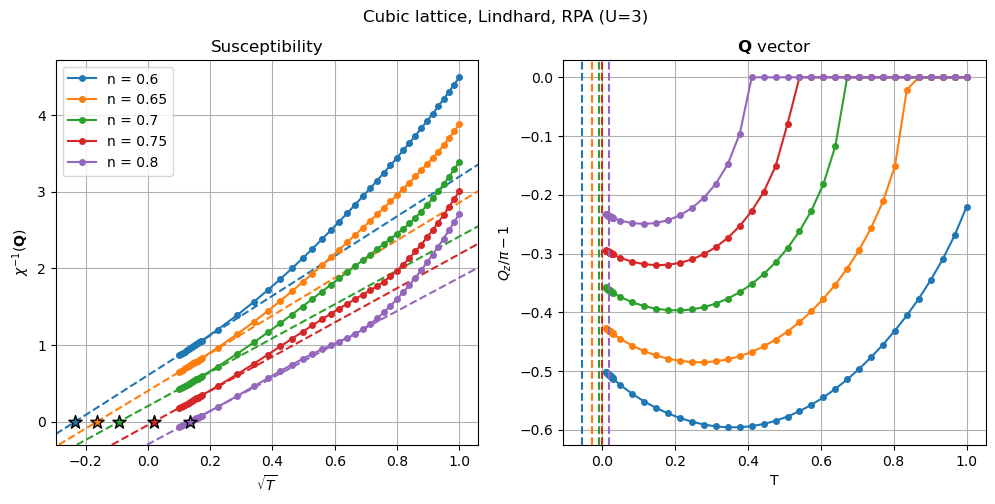

In [ ]:
U = 3
n_list = np.linspace(0.6, 0.8, 5)
T_list = np.concatenate([np.linspace(0.01, 0.05, 15), np.linspace(0.05, 1., 30)])
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 150
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5, fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=5)]: Using backend LokyBackend with 5 concurrent workers.


Starting serial run at: 2026-05-10 17:59:35.585461
Starting serial run at: 2026-05-10 17:59:35.585646
Starting serial run at: 2026-05-10 17:59:35.594730
Starting serial run at: 2026-05-10 17:59:35.644949
Starting serial run at: 2026-05-10 17:59:35.649892


[Parallel(n_jobs=5)]: Done   2 out of   5 | elapsed: 29.6min remaining: 44.4min
[Parallel(n_jobs=5)]: Done   3 out of   5 | elapsed: 29.6min remaining: 19.8min


n = 0.6 : ampl = 5.141360968304476, exp = 0.8286329906313528, Tc = -0.10256241385732705
n = 0.65 : ampl = 3.049158557617126, exp = 0.5967846345287959, Tc = -0.041936861623017956
n = 0.7 : ampl = 2.8060659515535886, exp = 0.6170568093533398, Tc = -0.023332999882773917
n = 0.75 : ampl = 3.231975658670455, exp = 0.7190401046828452, Tc = -0.0070595306387989795
n = 0.8 : ampl = 2.624655117430896, exp = 0.6474357254088626, Tc = 0.01613106626156504


[Parallel(n_jobs=5)]: Done   5 out of   5 | elapsed: 29.7min finished


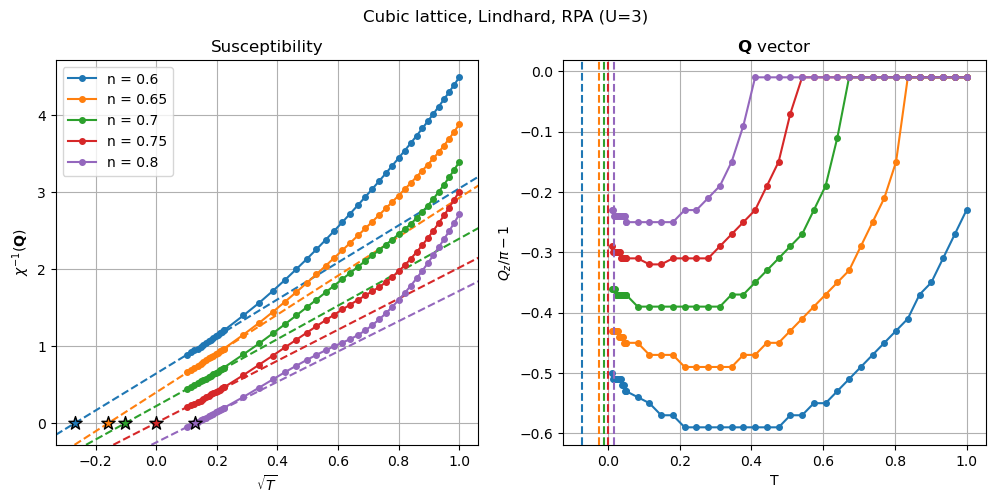

In [57]:
U = 3
n_list = np.linspace(0.6, 0.8, 5)
T_list = np.concatenate([np.linspace(0.01, 0.05, 15), np.linspace(0.05, 1., 30)])
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard, RPA (U={U})'

nk = 200
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'lindhard', 'refine': False} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=5)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    Tc = results['Xc']
    ampl = results['ampl']
    gamma = results['gamma']
    print(f"n = {n} : ampl = {ampl}, exp = {gamma}, Tc = {Tc}")
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1), x_exp=0.5, fit=True,
                        title=title, label=f'n = {n}', figure=fig)
    
    _, axs = fig
    color = axs[0].lines[-1].get_color()
    #axs[0].plot(T_list**0.5, critical1(T_list, ampl, gamma, Tc))
    axs[0].scatter(-fit[1]/fit[0], 0., marker='*', s=100, edgecolors='black', color=color, zorder=100)
    axs[1].axvline(np.sign(-fit[1]/fit[0])*(fit[1]/fit[0])**2, linestyle='--', color=color, zorder=100)

plt.show()

[Parallel(n_jobs=3)]: Using backend LokyBackend with 3 concurrent workers.
[Parallel(n_jobs=3)]: Done   3 out of   3 | elapsed:   14.4s finished


n = 0.88 : exp = 1.9563938131252145, ampl = 3.104671941888524
n = 0.89 : exp = 2.0984586510984466, ampl = 3.9195404300142758
n = 0.9 : exp = 1.5003918247636474, ampl = 3.074509862301342


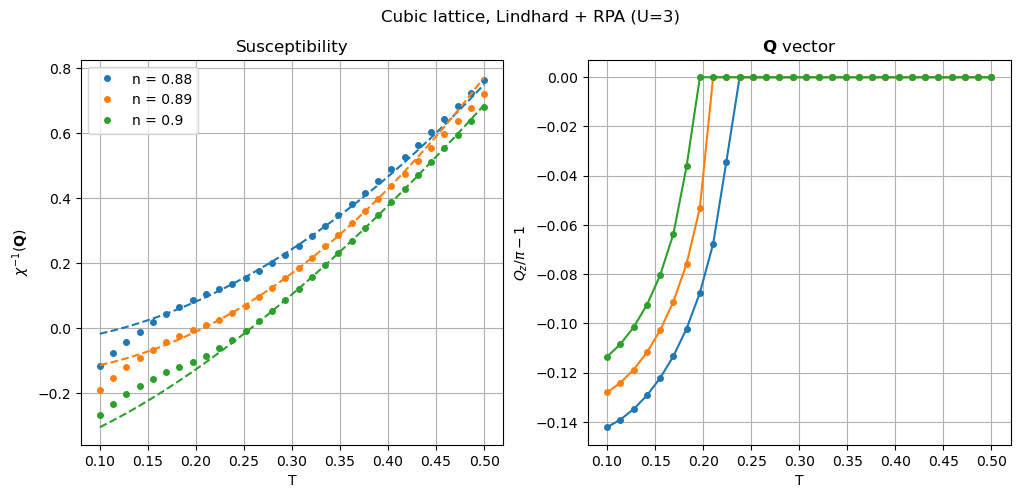

In [13]:
U = 3
n_list = np.linspace(0.88, 0.9, 3)
T_list = np.linspace(0.1, 0.5, 30)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Lindhard + RPA (U={U})'

nk = 50
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'fit_type': critical1} for par_dict in par_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=3)

fig = None
for results in results_list:
    n = results['par_list'][0]['n']
    ampl = results['ampl']
    gamma = results['gamma']
    c = results['c']
    print(f'n = {n} : exp = {gamma}, ampl = {ampl}')
    fig, fit = pcut_chi(results, 'T', plot_Q=(0,0,1),
                        title=title, label=f'n = {n}', figure=fig, styles=('o','o-'))
    _, axs = fig
    axs[0].plot(T_list, critical1(T_list, ampl, gamma, c), '--')

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-08 08:47:09.601029
Starting serial run at: 2026-05-08 08:47:09.602177
Starting serial run at: 2026-05-08 08:47:09.609273
Starting serial run at: 2026-05-08 08:47:09.638499
Starting serial run at: 2026-05-08 08:47:09.638526
Starting serial run at: 2026-05-08 08:47:09.649912
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:    2.5s remaining:    5.0s
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:    2.5s remaining:    2.5s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:    2.6s remaining:    1.3s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:    2.6s finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:   33.5s remaining:  1.1min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:   34.1s remaining:   34.1s
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:   34.2s remaining:   17.1s
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:   34.5s finished

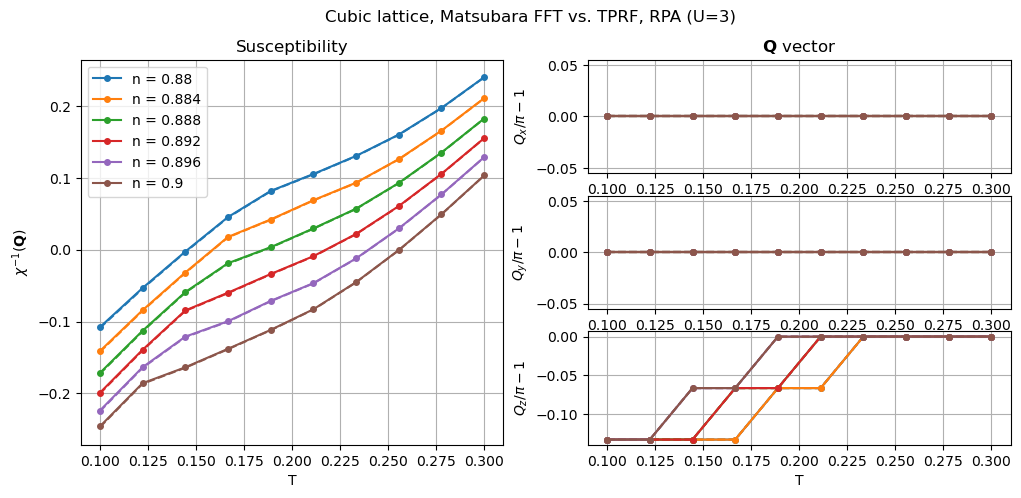

In [23]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 10)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. TPRF, RPA (U={U})'

nk = 30
n_iw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_fft', 'n_iw': n_iw, 'n_iw_extr': True} for par_dict in par_list]
results_list_fft = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'method': 'matsubara_tprf', 'n_iw': n_iw} for par_dict in par_list]
results_list_tprf = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_fft, res_tprf in zip(results_list_fft, results_list_tprf):
    n = res_fft['par_list'][0]['n']
    fig, fit = pcut_chi(res_fft, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_tprf, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:  4.4min remaining:  8.8min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:  4.4min remaining:  4.4min
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:  4.4min remaining:  2.2min
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:  4.4min finished
[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.
[Parallel(n_jobs=6)]: Done   2 out of   6 | elapsed:  2.8min remaining:  5.6min
[Parallel(n_jobs=6)]: Done   3 out of   6 | elapsed:  2.8min remaining:  2.8min
[Parallel(n_jobs=6)]: Done   4 out of   6 | elapsed:  2.9min remaining:  1.4min
[Parallel(n_jobs=6)]: Done   6 out of   6 | elapsed:  2.9min finished


n = 0.88 : exp_mats = 0.0005452852983804424, exp_lindh = 0.0005224226531031134
n = 0.884 : exp_mats = 0.0009300026960166454, exp_lindh = 0.0008800588317434134
n = 0.888 : exp_mats = 2.8195406908119476, exp_lindh = 2.7914200618091267
n = 0.892 : exp_mats = 2.6175103108254896, exp_lindh = 2.6188962820818973
n = 0.896 : exp_mats = 2.199284186562852, exp_lindh = 2.2001745313513172
n = 0.9 : exp_mats = 1.960022509206003, exp_lindh = 1.9606985361478504


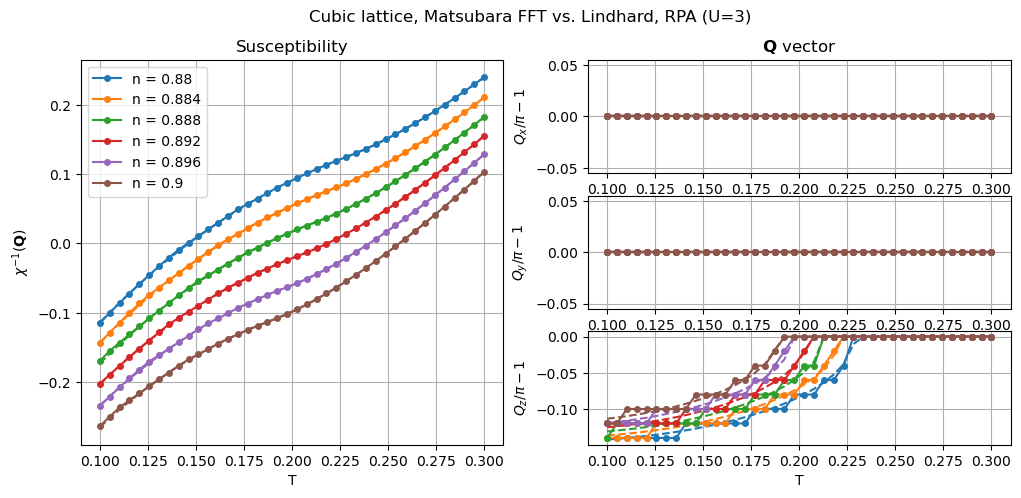

In [24]:
U = 3
n_list = np.linspace(0.88, 0.9, 6)
T_list = np.linspace(0.1, 0.3, 40)
par_list = [{'U': U, 'n': n, 'T': T_list} for n in n_list]
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U})'

nk = 100
n_iw = 64
sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'method': 'matsubara_fft', 'n_iw': n_iw, 'n_iw_extr': True} for par_dict in par_list]
results_list_mats = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'refine': True} for par_dict in par_list]
results_list_lindh = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6)

fig = None
for res_mats, res_lindh in zip(results_list_mats, results_list_lindh):
    n = res_mats['par_list'][0]['n']
    print(f"n = {n} : exp_mats = {res_mats['gamma']}, exp_lindh = {res_lindh['gamma']}")
    fig, fit = pcut_chi(res_mats, 'T', plot_Q=(1,1,1),
                        title=title, label=f'n = {n}', figure=fig)
    _, ax = fig
    color = ax[0].lines[-1].get_color()
    fig, fit = pcut_chi(res_lindh, 'T', plot_Q=(1,1,1),
                        title=title, figure=fig, color=color, styles=('--','--'))

plt.show()

[Parallel(n_jobs=4)]: Using backend LokyBackend with 4 concurrent workers.


Starting serial run at: 2026-05-07 20:46:14.200291
Starting serial run at: 2026-05-07 20:46:14.244642
Starting serial run at: 2026-05-07 20:46:14.251451
Starting serial run at: 2026-05-07 20:46:14.256328
[Parallel(n_jobs=4)]: Done   1 tasks      | elapsed:  1.8min
[Parallel(n_jobs=4)]: Done   2 out of   4 | elapsed:  2.1min remaining:  2.1min
[Parallel(n_jobs=4)]: Done   4 out of   4 | elapsed:  4.5min finished


Completed 15 jobs in 471.72 seconds | U=3.000, T=0.050, n=0.700
Completed 15 jobs in 290.38 seconds | U=3.000, T=0.050, n=0.700


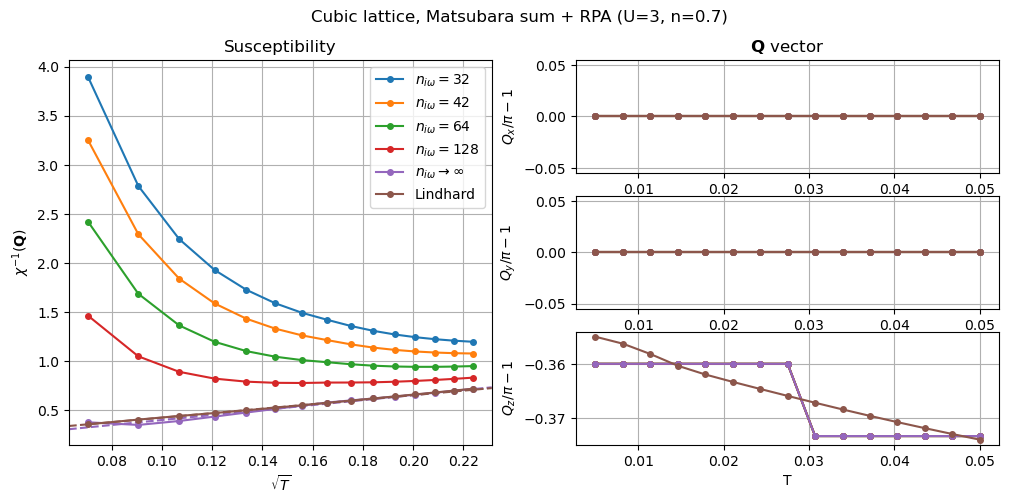

In [ ]:
U = 3
n = 0.7
T_list = np.linspace(0.005, 0.05, 15)
par_dict = {'U': U, 'n': n, 'T': T_list}
title = f'Cubic lattice, Matsubara FFT vs. Lindhard, RPA (U={U}, n={n})'

nk = 150
n_iw_list = 128//np.array([4,3,2,1])

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'n_iw': n_iw, 'n_iw_extr': False, 'method': 'matsubara_fft'} for n_iw in n_iw_list]
results_list = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=4)

fig = None
for results in results_list:
    n_iw = results['n_iw']
    fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=False, x_exp=0.5, title=title, label=f'$n_{{i\omega}}={n_iw}$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk, method='matsubara_fft', n_iw=n_iw_list[-1], n_iw_extr=True)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label=r'$n_{{i\omega}}\to\infty$', figure=fig)

results = sweep_chirpa(par_dict, nk=nk)
fig, fit = pcut_chi(results, 'T', plot_Q=(1,1,1), fit=True, x_exp=0.5, title=title, label='Lindhard', figure=fig)

plt.show()

In [8]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 15)

nk = 150
file = f'{save_dir}/nTdiag_U3tp0.00'
if os.path.exists(file):
    results = HDFread_list(f'{save_dir}/nTdiag_U3tp0.00', ['Xc'])
    n_old = [par_list[0]['n'] for par_list in results['par_list']]
    Tc_old = [x[0] for x in results['Xc']]
    Tc = np.interp(n_list, n_old, Tc_old)
else:
    print(f'file {file} does not exist!')

par_list = []
for i, n in enumerate(n_list):
    par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.01)})

sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'fit_type': [critical1, critical2, critical3]} for par_dict in par_list]
results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=12, save_file=file)

[Parallel(n_jobs=12)]: Using backend LokyBackend with 12 concurrent workers.
Starting serial run at: 2026-05-11 00:33:22.221937
Starting serial run at: 2026-05-11 00:33:22.227604
Starting serial run at: 2026-05-11 00:33:22.247086
Starting serial run at: 2026-05-11 00:33:22.247179
Starting serial run at: 2026-05-11 00:33:22.248501
Starting serial run at: 2026-05-11 00:33:22.248513


Starting serial run at: 2026-05-11 00:33:22.335885
Starting serial run at: 2026-05-11 00:33:22.336393
Starting serial run at: 2026-05-11 00:33:22.385708
Starting serial run at: 2026-05-11 00:33:22.393119
Starting serial run at: 2026-05-11 00:33:22.393119
Starting serial run at: 2026-05-11 00:33:22.397540
[Parallel(n_jobs=12)]: Done   1 tasks      | elapsed:  4.8min
[Parallel(n_jobs=12)]: Done   4 out of  24 | elapsed:  5.1min remaining: 25.4min
[Parallel(n_jobs=12)]: Done   7 out of  24 | elapsed:  5.2min remaining: 12.6min
[Parallel(n_jobs=12)]: Done  10 out of  24 | elapsed:  5.2min remaining:  7.3min



Fit failed: Optimal parameters not found: The maximum number of function evaluations is exceeded.


[Parallel(n_jobs=12)]: Done  13 out of  24 | elapsed:  9.9min remaining:  8.4min



Fit failed: Optimal parameters not found: The maximum number of function evaluations is exceeded.


[Parallel(n_jobs=12)]: Done  16 out of  24 | elapsed: 10.4min remaining:  5.2min
[Parallel(n_jobs=12)]: Done  19 out of  24 | elapsed: 10.6min remaining:  2.8min
[Parallel(n_jobs=12)]: Done  22 out of  24 | elapsed: 10.9min remaining:   59.7s
[Parallel(n_jobs=12)]: Done  24 out of  24 | elapsed: 11.0min finished


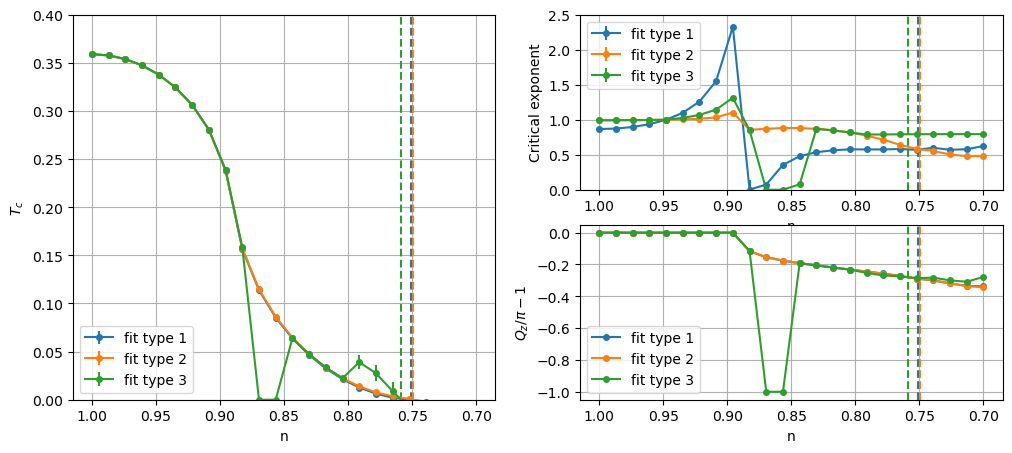

In [10]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_z/\pi-1$')

results = HDFread_list(f'{save_dir}/nTdiag_U3tp0.00', ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
n_fits = len(results['Xc'][0])

for i in range(n_fits):
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[i][-1]-1 for Q in results['Qc']]
    Xc = [x[i] for x in results['Xc']]
    Xc_err = [x[i] for x in results['Xc_err']]
    gamma = [x[i] for x in results['gamma']]
    gamma_err = [x[i] for x in results['gamma_err']]

    ax[0].errorbar(n_list, Xc, Xc_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    ax[1].errorbar(n_list, gamma, gamma_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"fit type {i+1}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., Xc, n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

IndexError: list index out of range

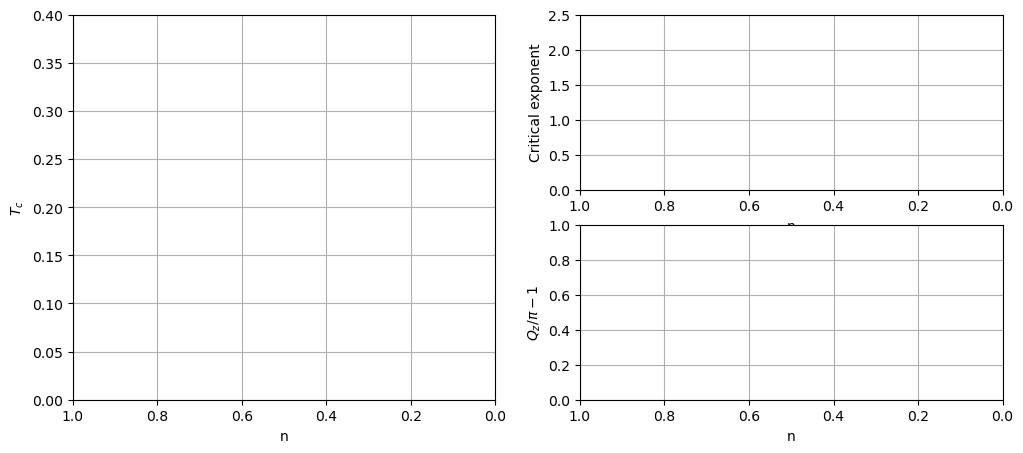

In [11]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_z/\pi-1$')

results = HDFread_list(f'{save_dir}/nTdiag_U3tp0.00', ['c', 'c_err', 'd', 'd_err', 'Qc'])
n_fits = len(results['c'][0])

for i in range(n_fits):

    if i != 2:
        continue
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[i][-1]-1 for Q in results['Qc']]
    Xc = [x[i] for x in results['c']]
    Xc_err = [x[i] for x in results['c_err']]
    gamma = [x[0] for x in results['d']]
    gamma_err = [x[0] for x in results['d_err']]

    ax[0].errorbar(n_list, Xc, Xc_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    ax[1].errorbar(n_list, gamma, gamma_err, fmt='o-', label=f"fit type {i+1}", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"fit type {i+1}", markersize=4)
    color = line[0].get_color()

    n_crit = np.interp(0., Xc, n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

plt.savefig(f'{save_dir}/fit_type.png', dpi=100)
plt.show()

In [25]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 15)

nk = 150
n_iw = 128
tp_list = [0.05, 0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.005)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'method': 'matsubara_fft', 'n_iw': n_iw, 'n_iw_extr': True} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-08 08:55:13.401231
Starting serial run at: 2026-05-08 08:55:13.419401
Starting serial run at: 2026-05-08 08:55:13.427826
Starting serial run at: 2026-05-08 08:55:13.446751
Starting serial run at: 2026-05-08 08:55:13.478344
Starting serial run at: 2026-05-08 08:55:13.487991
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 11.5min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 11.5min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 34.2min


Starting serial run at: 2026-05-08 09:29:23.800798


Starting serial run at: 2026-05-08 09:29:24.138076
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 34.2min remaining: 17.1min


Starting serial run at: 2026-05-08 09:29:24.480865


...

Starting serial run at: 2026-05-08 09:53:42.734106


Starting serial run at: 2026-05-08 10:05:11.039493


Starting serial run at: 2026-05-08 10:05:11.707068


Starting serial run at: 2026-05-08 10:05:12.029603


Starting serial run at: 2026-05-08 10:05:12.371180
[Parallel(n_jobs=6)]: Done  13 out of  21 | elapsed: 35.6min remaining: 21.9min
[Parallel(n_jobs=6)]: Done  16 out of  21 | elapsed: 35.7min remaining: 11.2min
[Parallel(n_jobs=6)]: Done  19 out of  21 | elapsed: 44.3min remaining:  4.7min
[Parallel(n_jobs=6)]: Done  21 out of  21 | elapsed: 44.3min finished


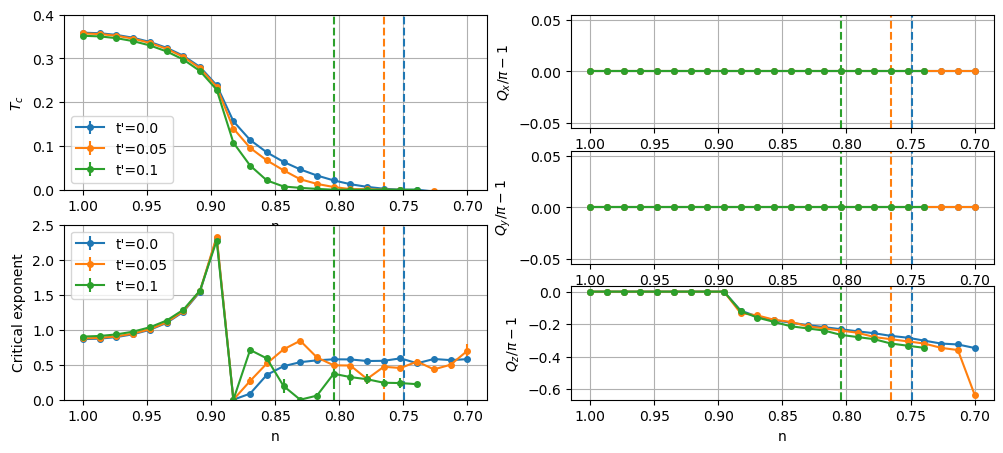

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')
    a.invert_xaxis()

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., 0.05, 0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/postp.png', dpi=100)
plt.show()

In [3]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.05, 15)

nk = 150
n_iw = 128
tp_list = [-0.05, -0.1]
for i, tp in enumerate(tp_list):

    file = f'{save_dir}/nTdiag_U3tp{tp:.2f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')
    
    par_list = []
    for i, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[i], 0.005)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'tp': tp, 'method': 'matsubara_fft', 'n_iw': n_iw, 'n_iw_extr': True} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-05-08 12:04:58.688822
Starting serial run at: 2026-05-08 12:04:58.728301
Starting serial run at: 2026-05-08 12:04:58.731410
Starting serial run at: 2026-05-08 12:04:58.775898
Starting serial run at: 2026-05-08 12:04:58.795581
Starting serial run at: 2026-05-08 12:04:58.798235
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed: 11.6min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed: 11.7min
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 34.7min
/home/ctort/miniconda3/envs/triqs/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Starting serial run at: 2026-05-08 12:39:39.593711


Starting serial run at: 2026-05-08 12:39:41.514927
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 34.7min remaining: 17.4min


Starting serial run at: 2026-05-08 12:39:42.051541


...

Starting serial run at: 2026-05-08 13:14:18.569095
[Parallel(n_jobs=6)]: Done  10 out of  19 | elapsed: 23.1min remaining: 20.8min


Starting serial run at: 2026-05-08 13:14:19.523697


Starting serial run at: 2026-05-08 13:14:19.929989
[Parallel(n_jobs=6)]: Done  12 out of  19 | elapsed: 23.1min remaining: 13.5min


Starting serial run at: 2026-05-08 13:14:20.234814


Starting serial run at: 2026-05-08 13:14:20.590914
[Parallel(n_jobs=6)]: Done  14 out of  19 | elapsed: 34.4min remaining: 12.3min
[Parallel(n_jobs=6)]: Done  16 out of  19 | elapsed: 34.4min remaining:  6.4min
[Parallel(n_jobs=6)]: Done  19 out of  19 | elapsed: 43.7min finished


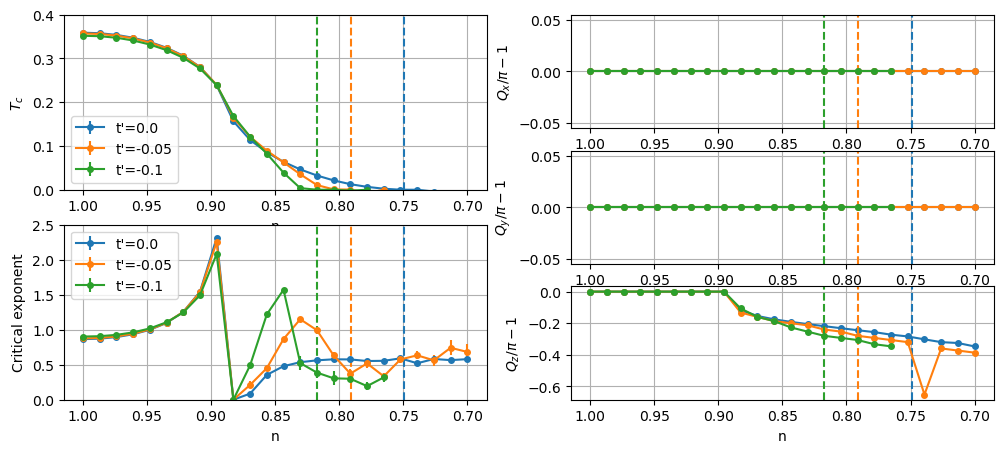

In [5]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(2,2,1),
      fig.add_subplot(2,2,3),
      fig.add_subplot(3,2,2),
      fig.add_subplot(3,2,4),
      fig.add_subplot(3,2,6)]

for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(0., 0.4)
ax[1].set_ylim(0., 2.5)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Q_x/\pi-1$')
ax[3].set_ylabel(r'$Q_y/\pi-1$')
ax[4].set_ylabel(r'$Q_z/\pi-1$')

tp_list = [0., -0.05, -0.1]
for i, tp in enumerate(tp_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3tp{tp:.2f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qi = [[Q[i]-1 for Q in results['Qc']] for i in range(3)]

    line = ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"t'={tp}", markersize=4)
    for i, a in enumerate(ax[2:]):
        a.plot(n_list, Qi[i], 'o-', markersize=4)
    
    color = line[0].get_color()

    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        a.axvline(n_crit, linestyle='--', color=color)
        a.invert_xaxis()

    ax[0].legend()
    ax[1].legend()

plt.savefig(f'{save_dir}/negtp.png', dpi=100)
plt.show()

In [ ]:
save_dir = f'data/{dim}d/rpa_ba'

In [ ]:
U = 3
n_list = np.linspace(0.7, 1., 24)
T_list = np.linspace(0., 0.01, 6)

nk = 150

Gamma_list = [0., 0.01, 0.025, 0.05]
for i, Gamma in enumerate(Gamma_list):

    file = f'{save_dir}/nTdiag_U3g{Gamma:.3f}'
    if os.path.exists(file):
        results = HDFread_list(file, ['Xc'])
        n_old = [par_list[0]['n'] for par_list in results['par_list']]
        Tc = np.interp(n_list, n_old, results['Xc'])
    else:
        print(f'file {file} does not exist!')

    par_list = []
    for j, n in enumerate(n_list):
        par_list.append({'U': U, 'n': n, 'T': T_list + max(Tc[j], 0.001)})

    sweep_dict = [{'par_dict': par_dict, 'nk': nk, 'fit': True, 'nk_avg': (10,1), 
                   'S_iwk_list': [1j*Gamma_list[i] for _ in T_list]} for par_dict in par_list]
    results = sweep_parallel(sweep_chirpa, sweep_dict, n_jobs=6, save_file=file)

    Tc = np.array([res['Xc'] for res in results])
    i_crit = np.argwhere(Tc > 0)[0,0]
    n_list = n_list[max(i_crit-2,0):]

[Parallel(n_jobs=6)]: Using backend LokyBackend with 6 concurrent workers.


Starting serial run at: 2026-04-27 03:12:13.873295
Starting serial run at: 2026-04-27 03:12:13.874813
Starting serial run at: 2026-04-27 03:12:13.916441
Starting serial run at: 2026-04-27 03:12:13.949544
Starting serial run at: 2026-04-27 03:12:13.950203
Starting serial run at: 2026-04-27 03:12:13.970494
[Parallel(n_jobs=6)]: Done   1 tasks      | elapsed:  5.8min
[Parallel(n_jobs=6)]: Done   6 tasks      | elapsed:  5.9min


Starting serial run at: 2026-04-27 03:23:25.637681


Starting serial run at: 2026-04-27 03:23:31.738524


Starting serial run at: 2026-04-27 03:23:34.419550


...

Starting serial run at: 2026-04-27 04:32:14.238640


Starting serial run at: 2026-04-27 04:32:19.953491


Starting serial run at: 2026-04-27 04:32:22.015293


Starting serial run at: 2026-04-27 04:32:22.618561


Starting serial run at: 2026-04-27 04:32:23.565854
[Parallel(n_jobs=6)]: Done  13 tasks      | elapsed: 16.3min
[Parallel(n_jobs=6)]: Done  16 out of  24 | elapsed: 16.8min remaining:  8.4min
[Parallel(n_jobs=6)]: Done  19 out of  24 | elapsed: 21.9min remaining:  5.8min
[Parallel(n_jobs=6)]: Done  22 out of  24 | elapsed: 22.3min remaining:  2.0min
[Parallel(n_jobs=6)]: Done  24 out of  24 | elapsed: 22.5min finished


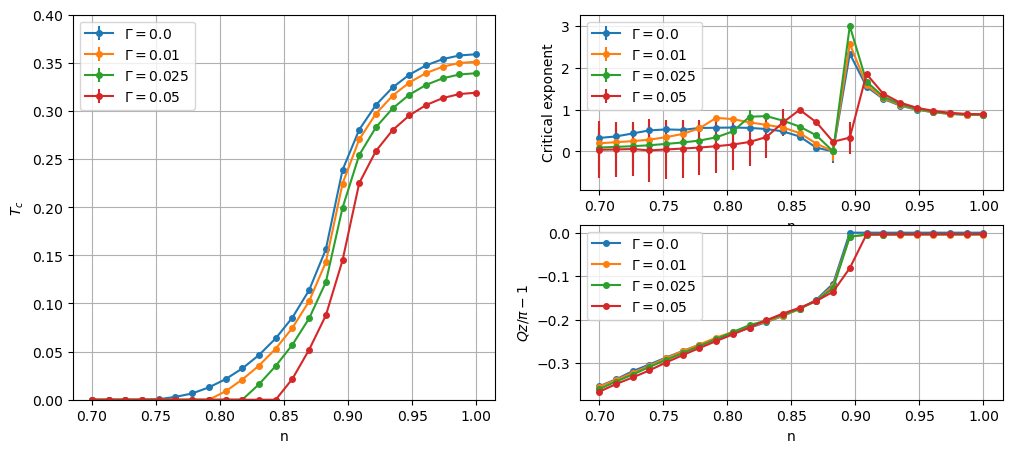

In [ ]:
fig = plt.figure(figsize=(12, 5))
ax = [fig.add_subplot(1,2,1),
      fig.add_subplot(2,2,2),
      fig.add_subplot(2,2,4)]
for a in ax:
    a.grid()
    a.set_xlabel('n')

ax[0].set_ylim(0., 0.4)

ax[0].set_ylabel('$T_c$')
ax[1].set_ylabel('Critical exponent')
ax[2].set_ylabel(r'$Qz/\pi-1$')

Gamma_list = [0., 0.01, 0.025, 0.05]
for i, Gamma in enumerate(Gamma_list):

    results = HDFread_list(f'{save_dir}/nTdiag_U3g{Gamma:.3f}', 
                 ['Xc', 'Xc_err', 'gamma', 'gamma_err', 'Qc'])
    
    n_list = [par_list[0]['n'] for par_list in results['par_list']]
    Qz = [Q[-1]-1 for Q in results['Qc']]

    ax[0].errorbar(n_list, results['Xc'], results['Xc_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    ax[1].errorbar(n_list, results['gamma'], results['gamma_err'], fmt='o-', label=f"$\Gamma={Gamma}$", markersize=4)
    line = ax[2].plot(n_list, Qz, 'o-', label=f"$\Gamma={Gamma}$", markersize=4)

    color = line[0].get_color()
    n_crit = np.interp(0., results['Xc'], n_list)
    for a in ax:
        #a.axvline(n_crit, linestyle='--', color=color)
        a.legend()

    for a in ax:
        a.legend()

plt.show()